<a href="https://colab.research.google.com/gist/kimchi-chisung/596f1e9626d1a86746b32838c3323247/a10_code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CEE6501 — Coding Assignment, Week 10

**Assigned:** 03/20/2026 (Week 10)  
**Due:** 03/30/2026

**Canvas Submission Link:**  <https://gatech.instructure.com/courses/517856/assignments/2320768>

---

## Logistics

### 💻 Assignment Format

This is a **coding assignment**.

- Complete the assignment by **executing and completing all tasks in the notebook cells below**
- The notebook should be run and completed in **Google Colab**
- Your submission **must be a link to a functioning Google Colab notebook**

You may use any local tools (VS Code, JupyterLab, etc.) while working, but the **final submitted work must run correctly in Colab**.


### 📤 Submission Instructions

- Name this notebook as: `LastName_A#_code.ipynb`
- Submit **one link** to your Google Colab notebook on Canvas
- Ensure that:
  - Permissions on the file are properly set for others to access
  - All cells run **top-to-bottom without errors**
  - All required outputs are visible
  - The notebook reflects your final answers

### ✅ Checklist Before Submitting

- [ ] All notebook cells completed
- [ ] Code runs without errors from a fresh runtime
- [ ] Outputs and plots are clearly visible
- [ ] Colab link opens and runs correctly
- [ ] Correct notebook submitted on Canvas

### 🤝 Collaboration / AI tools
You may discuss concepts with classmates and you may use AI tools to help you learn,
but **your submitted code must be written by you and you must understand it**.
If you used outside help, add a short note in the final reflection cell.

---
---

## --- Google Colab environment setup ---

The cell below only needs to run when the notebook is opened in Google Colab.

This code will not affect code execution locally in VS-code + conda environment.

Google Colab starts each session with its own **preloaded versions** of common Python (currently 3.12.12) and Python packages (NumPy, SciPy, etc.).  
If we install different package versions once loaded, Python cannot switch to them while it is already running.

### What will happen
When you run the setup cell below in Google Colab:

1. The required package versions are installed
2. The runtime is **automatically restarted** so the new versions can be loaded  
3. You may see the message **“Your session crashed for an unknown reason.”**  
   → This is expected and normal

After the restart, rerun the notebook and check the **version check cell** to confirm package versions are correct.

### Runtime menu notes
- **Runtime → Restart session**  
  Restarts Python but keeps installed packages and saved files

- **Runtime → Disconnect and delete runtime**  
  Resets Colab completely to its default environment (packages will need to be reinstalled)

In [ ]:
# ============================================================
# Google Colab environment setup (pinned versions)
# ============================================================

import sys
import os
import subprocess

if "google.colab" in sys.modules:
    print("Running in Google Colab")
    print("Python version:", sys.version.split()[0])

    # ---- Required package versions --------------------------
    requirements = {
        "numpy": "2.4.0",
        "scipy": "1.16.3",
        "matplotlib": "3.10.8",
        "pandas": "2.3.3",
        "plotly": "6.5.2"
    }

    # ---- Check currently loaded versions --------------------
    restart_needed = False

    for pkg, required_version in requirements.items():
        try:
            module = __import__(pkg)
            installed_version = module.__version__
        except Exception:
            installed_version = None

        print(f"{pkg}: {installed_version} (required: {required_version})")

        if installed_version != required_version:
            restart_needed = True

    # ---- Install if needed ----------------------------------
    if restart_needed:
        print("\nInstalling pinned package versions...")

        pip_args = [
            f"{pkg}=={ver}" for pkg, ver in requirements.items()
        ]

        subprocess.check_call(
            [sys.executable, "-m", "pip", "install", "-q", *pip_args]
        )

        print("Installation complete.")
        print("Restarting runtime to load correct packages...")

        # This will appear as a "crash" in Colab — expected behavior
        os.kill(os.getpid(), 9)

    else:
        print("\nAll required package versions already installed.")

else:
    print("Not running in Google Colab — setup skipped.")
    print("Python version:", sys.version.split()[0])

Not running in Google Colab — setup skipped.
Python version: 3.12.12


## Imports & Version Check

Run this cell once before starting the assignment to import packages.

In [ ]:
import numpy as np
import scipy
import matplotlib
import pandas as pd
import plotly

print("numpy:", np.__version__)
print("scipy:", scipy.__version__)
print("matplotlib:", matplotlib.__version__)
print("pandas:", pd.__version__)
print("plotly:", plotly.__version__)

import matplotlib.pyplot as plt
import plotly.graph_objects as go

np.set_printoptions(precision=3, suppress=True)

numpy: 2.0.2
scipy: 1.16.3
matplotlib: 3.10.0
pandas: 2.2.2
plotly: 5.24.1


---
---

## Assignment Instructions

In this assignment, you will build on your frame-analysis code from `A8_code.ipynb`:

1. Extend your solver to handle **prescribed support displacements** (support settlements).
2. Extend your solver to handle **temperature effects**
3. Extend your solver to handle **fabrication error effects**

Confirm your code is correct by validating using your hand calculated solutions for the all the questions in `A10_written.md`
- Question 1 — Support Displacements
- Question 2 — Temperature Effects
- Question 3 — Fabrication / Fit-up Errors

### Response (For each question)

Address the following points:

- **Verification:**  
  Confirm whether your computed results match your hand calculations.  
  Identify which quantities you compared (for example: key displacements, reactions, or member end forces).

- **Key results:**  
  Summarize the most important outcomes from your analysis, including representative:
  - **nodal displacements**
  - **support reactions**
  - **member end forces**

- **Reasonableness check:**  
  Briefly explain why the results make sense from a **structural mechanics perspective** (for example: expected deformation direction, magnitude of reactions, or moment distribution).

### Notes
- Use consistent DOF ordering (as in lecture). For a 2D frame node, a common ordering is:
  - $[u_x,\; u_y,\; \theta_z]$ per node
- Clearly document your conventions at the top of your code.
- Use **plots** to help validate and interpret results.

---

In [ ]:

# Extend your solver from A8_code.ipynb to add in support displacements, temperature effects, and fabrication errors
#
# Add your code below (use as many cells as you need). Make sure to include comments and explanations of your code.
#
# Keep your code modular and organized


In [ ]:
# code from hw7
def plot_deformed_frame_2d(nodes, elements, U, scale=1.0, npts=50, disp_boost=5.0, node_boost=50.0): # I've added two more scale factors for visualize translation better
    """
    Problem 2 — Frame

    Plot undeformed and deformed shape for a 2D frame

    Inputs
    ------
    nodes : dict
        {node_id: (x, y)}
    elements : dict
        {elem_id: (i, j)}
    U : array-like
        Global displacement vector with [ux, uy, th] per node
    scale : float
        Deformation scale factor
    npts : int
        Number of sample points per element

    Tasks
    -----
    1) Loop through elements
    2) Compute L, c, s
    3) Extract (ux_i, uy_i, th_i, ux_j, uy_j, th_j) from U
    4) Compute ux(x) (linear) and uy(x) (cubic)
    5) Transform local displacement to global
    6) Plot undeformed and deformed structures
    """
    # TODO: implement

    plt.figure(figsize=(7, 7))
    plt.plot([], [], "b-", label="undeformed")
    plt.plot([], [], "r-", label="deformed")

    for eid,node_num in elements.items():
        i, j = node_num[0], node_num[1]
        xi, yi = nodes[i]
        xj, yj = nodes[j]

        c, s, L = element_csl((xi, yi), (xj, yj))

        u_e_g = extract_element_dofs_frame(U, i, j)         # global element displacement
        T = frame_Transformation_matrix(c, s)
        u_e_l = T @ u_e_g                                   # local element displacement
        ux_i, uy_i, th_i, ux_j, uy_j, th_j = u_e_l

        # undeformed
        plt.plot([xi, xj], [yi, yj], "b-")

        x = np.linspace(0.0, L, npts)
        x_und = xi + c * x
        y_und = yi + s * x

        # local axial + bending
        ux_loc = (1 - x/L) * ux_i + (x/L) * ux_j            # Linear interpolation for axial displacement
        N1, N2, N3, N4 = shape_functions(x, L)
        uy_loc = N1*uy_i + N2*th_i + N3*uy_j + N4*th_j      # Linear interpolation for vertical displacement + curved shape

        # local->global displacement field                  # Transform local displacement field into global displacement
        ux_g =  c*ux_loc - s*uy_loc
        uy_g =  s*ux_loc + c*uy_loc

        # I made this section for visualize translation better (it's related with "disp_boost" and "node_boost")
        # get nodal translations in GLOBAL coords
        ui_g = extract_node_dofs_frame(U, i)[:2]            # (ux,uy)
        uj_g = extract_node_dofs_frame(U, j)[:2]

        alpha = (x / L)[:, None]                            # (npts,1)
        u_node_g = (1 - alpha) * ui_g + alpha * uj_g        # (npts,2)

        # combine: (1) shape-based field + (2) boosted nodal translations
        x_def = x_und + scale * (disp_boost * ux_g + node_boost * u_node_g[:, 0])
        y_def = y_und + scale * (disp_boost * uy_g + node_boost * u_node_g[:, 1])

        plt.plot(x_def, y_def, "r-")

    plt.axis("equal")
    plt.grid(True, alpha=0.3)
    plt.xlabel("x (m)")
    plt.ylabel("y (m)")
    plt.title(f"Frame Deformed Shape")
    # plt.legend(loc="best")
    plt.legend(loc="upper left", bbox_to_anchor=(1.02, 1.0), borderaxespad=0.0)
    plt.tight_layout()
    plt.show()

# Write any additional helper function(s) that you want to call from your plotting function

def shape_functions(x, L):
    xi = x / L
    N1 = 1 - 3*xi**2 + 2*xi**3
    N2 = L * (xi - 2*xi**2 + xi**3)
    N3 = 3*xi**2 - 2*xi**3
    N4 = L * (-xi**2 + xi**3)
    return N1, N2, N3, N4

def element_csl(xy_i, xy_j):
    xi, yi = xy_i
    xj, yj = xy_j
    dx = xj - xi
    dy = yj - yi
    L = float(np.hypot(dx, dy))
    c = float(dx / L)
    s = float(dy / L)
    return c, s, L

def frame_Transformation_matrix(c, s):
    # local = T @ global  (ux,uy,th) at i and j
    R = np.array([[ c, s, 0.0],
                  [-s, c, 0.0],
                  [0.0, 0.0, 1.0]], dtype=float)
    Z = np.zeros((3, 3), dtype=float)
    return np.block([[R, Z],
                     [Z, R]])

def extract_node_dofs_frame(U, nid):                  # U = [ux1, uy1, th1, ux2, uy2, th2, ...]
    i0 = 3*(nid-1)                                    # 1-based node id
    return U[i0:i0+3]                                 # output: [ux_n, uy_n, th_n]

def extract_element_dofs_frame(U, i, j):
    return np.hstack([extract_node_dofs_frame(U, i),
                      extract_node_dofs_frame(U, j)]) # output: [ux_i, uy_i, th_i, ux_j, uy_j, th_j]

In [ ]:
# helper_funcs_dsm.py

def assemble_global_stiffness_and_fef(
    ndof,
    k_list,
    T_list,
    Qf_list,
    map_list,
):
    """
    Assemble global stiffness matrix and global fixed-end force vector.

    Automatically handles 6-DOF (frame) and 4-DOF (truss/beam) elements.
    Parameters
    ----------
    ndof : int
        Total number of global degrees of freedom.

    k_list : list of ndarray
        List of local element stiffness matrices.
        Each matrix may be 6x6 (frame) or 4x4 (truss/beam).

    T_list : list of ndarray
        List of element transformation matrices corresponding
        to each k_local. Must be compatible in size.

    Qf_list : list of ndarray
        List of local fixed-end force vectors for each element.
        Size must match the element DOF count.

    map_list : list of array-like
        List of element DOF maps (1-based indexing).
        Each map defines where the element DOFs connect
        into the global DOF numbering.

    Returns
    -------
    K_global : ndarray (ndof x ndof)
        Assembled global stiffness matrix.

    F_fef_global : ndarray (ndof,)
        Assembled global fixed-end force vector.

    Notes
    -----
    - DOF maps are assumed to use 1-based indexing.
    - Internally converted to 0-based indexing for Python.
    - Assembly is dense; for large systems a sparse format
      should be used instead.
    """

    K_global = np.zeros((ndof, ndof), dtype=float)
    F_fef_global = np.zeros(ndof, dtype=float)

    nelem = len(k_list)

    for i in range(nelem):

        k_local = k_list[i]
        T = T_list[i]
        Qf_local = Qf_list[i]
        dof_map = map_list[i]  # 1-based indexing

        # Determine element DOF count automatically
        edof = k_local.shape[0]

        # Transform to global
        K = T.T @ k_local @ T
        F_fef = T.T @ Qf_local

        # Scatter-add
        for a in range(edof):
            A = dof_map[a] - 1  # convert to 0-based

            F_fef_global[A] += F_fef[a]

            for b in range(edof):
                B = dof_map[b] - 1
                K_global[A, B] += K[a, b]

    return K_global, F_fef_global


def partition_system(K, f, u, f_fef, dof_restrained_1based):
    ndof = K.shape[0]

    # Convert restrained DOFs to 0-based
    restrained_dofs = sorted(int(d) - 1 for d in dof_restrained_1based)

    # Free DOFs
    free_dofs = [i for i in range(ndof) if i not in restrained_dofs]

    # Partition stiffness matrix
    K_ff = K[np.ix_(free_dofs, free_dofs)]
    K_fr = K[np.ix_(free_dofs, restrained_dofs)]
    K_rf = K[np.ix_(restrained_dofs, free_dofs)]
    K_rr = K[np.ix_(restrained_dofs, restrained_dofs)]

    # Partition force vector
    f_f = f[free_dofs]
    f_r = f[restrained_dofs]

    # Partition displaced vector
    u_r = u[restrained_dofs]

    # Partition fixed-end forces
    f_fef_f = f_fef[free_dofs]
    f_fef_r = f_fef[restrained_dofs]

    return (
        K_ff,
        K_fr,
        K_rf,
        K_rr,
        f_f,
        f_r,
        u_r,
        f_fef_f,
        f_fef_r,
        free_dofs,
        restrained_dofs,
    )


def assemble_global_displacements(u_f, u_r, free_dofs, restrained_dofs):
    """
    Assemble the full global displacement vector u from partitioned results.
    """
    ndof_total = len(free_dofs) + len(restrained_dofs)
    u_global = np.zeros(ndof_total)

    if u_r is None:
        u_r = np.zeros(len(restrained_dofs))

    u_global[free_dofs] = u_f
    u_global[restrained_dofs] = u_r

    return u_global


def assemble_global_forces(f_f, F_r, free_dofs, restrained_dofs):
    """
    Assemble the full global force vector f from applied loads and reactions.
    """
    ndof_total = len(free_dofs) + len(restrained_dofs)
    f_global = np.zeros(ndof_total)

    f_global[free_dofs] = f_f
    f_global[restrained_dofs] = F_r

    return f_global

In [ ]:
# helper_funcs_output.py

def print_dsm_results(
    u_global,
    f_global_complete,
    dof_restrained_1based,
    dof_fictitious_1based=None,  # optional kwarg
    disp_in_mm=False,
    member_type="frame",
):
    ndof = len(u_global)
    rows = []

    # Ensure arrays
    dof_restrained_1based = np.atleast_1d(dof_restrained_1based)

    if dof_fictitious_1based is None:
        dof_fictitious_1based = np.array([], dtype=int)
    else:
        dof_fictitious_1based = np.atleast_1d(dof_fictitious_1based)

    restrained_set = {int(d) for d in dof_restrained_1based}
    fictitious_set = {int(d) for d in dof_fictitious_1based}

    member_type = member_type.lower()

    if member_type == "frame":
        dof_labels = ["u_x", "u_y", "theta"]
        translational_idx = {0, 1}
    elif member_type == "truss":
        dof_labels = ["u_x", "u_y"]
        translational_idx = {0, 1}
    elif member_type == "beam":
        dof_labels = ["u_y", "theta"]
        translational_idx = {0}
    else:
        raise ValueError("member_type must be 'frame', 'truss', or 'beam'")

    dof_per_node = len(dof_labels)

    for i in range(ndof):
        dof_1based = i + 1
        mod = i % dof_per_node
        dof_type = dof_labels[mod]

        if mod in translational_idx:
            disp = u_global[i] * (1000 if disp_in_mm else 1)
        else:
            disp = u_global[i]

        if dof_1based in fictitious_set:
            status = "Fictitious"
        elif dof_1based in restrained_set:
            status = "Fixed"
        else:
            status = "Free"

        rows.append([dof_1based, dof_type, status, disp, f_global_complete[i]])

    disp_unit = "mm" if disp_in_mm else "m"

    df = pd.DataFrame(
        rows,
        columns=[
            "DOF",
            "Type",
            "Status",
            f"Disp ({disp_unit} / rad)",
            "Load (kN / kN·m)",
        ],
    )

    print(df.to_string(index=False, float_format="%.3f"))


def print_element(
    e, u_global, m_1based, T, k, Qf, disp_in_mm=False, dec=3, rad_dec=4
):

    idx = m_1based - 1
    u = u_global[idx]
    v = T @ u
    q = k @ v + Qf

    scale = 1000 if disp_in_mm else 1
    unit = "mm" if disp_in_mm else "m"

    # Scale translations only (0,1,3,4) — rotations (2,5) untouched
    u_out = u.copy()
    v_out = v.copy()
    for j in [0, 1, 3, 4]:
        u_out[j] *= scale
        v_out[j] *= scale

    def fmt_disp(vec):
        parts = []
        for j, val in enumerate(vec):
            if j % 3 == 2:  # rotation (rad)
                parts.append(f"{val:.{rad_dec}f}")
            else:  # translation
                parts.append(f"{val:.{dec}f}")
        return "[" + ", ".join(parts) + "]"

    def fmt_force(vec):
        # forces (kN) and moments (kN·m) both use dec
        return "[" + ", ".join(f"{val:.{dec}f}" for val in vec) + "]"

    print(f"\nE{e}")
    print(f"u [{unit},rad]: {fmt_disp(u_out)}")
    print(f"v [{unit},rad]: {fmt_disp(v_out)}")
    print(f"q [kN,kN·m]: {fmt_force(q)}")


def print_element_truss(
    e,
    u_global,
    m_1based,
    T,
    k_local,
    Qf_local=None,
    disp_in_mm=False,
    dec=3,
):
    """
    Print element-level results for a 2D truss element.

    Parameters
    ----------
    e : int
        Element number for printing.
    u_global : (ndof,) array
        Global displacement vector.
    m_1based : (4,) array-like
        Global DOF map for this element (1-based indexing).
    T : (4,4) array
        Transformation matrix (global -> local).
    k_local : (4,4) array
        Local truss stiffness matrix (typically axial-only with 1/-1 pattern).
    Qf_local : (4,) array or None
        Local fixed-end / initial-force vector. If None, assumed zero.
        (Usually zero for trusses unless you model prestrain/temperature/etc.)
    disp_in_mm : bool
        If True, print translations in mm.
    dec : int
        Decimal places for printing.

    Prints
    ------
    - Element global displacement subvector u_e (translations)
    - Element local displacement vector u'_e
    - Element local end force vector q'_e
    - Axial force N (tension positive), computed as N = Fx_j' = -Fx_i'
    """

    idx = np.asarray(m_1based, dtype=int) - 1
    u_e = u_global[idx]  # [uix, uiy, ujx, ujy]

    if Qf_local is None:
        Qf_local = np.zeros(4, dtype=float)

    u_loc = T @ u_e
    q_loc = k_local @ u_loc + Qf_local  # [Fx_i', Fy_i', Fx_j', Fy_j']

    # scale translations for printing
    scale = 1000 if disp_in_mm else 1
    unit = "mm" if disp_in_mm else "m"
    u_out = u_e * scale
    uloc_out = u_loc * scale

    def fmt(vec):
        return "[" + ", ".join(f"{v:.{dec}f}" for v in vec) + "]"

    # axial force (tension +): for a pure truss, Fy' should be ~0
    # N_i = q_loc[0]  # Fx at i in local axis
    N_j = q_loc[2]  # Fx at j in local axis
    N = N_j  # report axial as end force at j (should equal -N_i)

    print(f"\nE{e} (Truss)")
    print(f"u_global [{unit}]: {fmt(u_out)}")
    print(f"u_local  [{unit}]: {fmt(uloc_out)}")
    print(f"q_local  [kN]: {fmt(q_loc)}")
    print(f"N (tension +) = {N:.{dec}f} kN\n")


def print_matrix_scaled(K, scale=1000, decimals=1, col_width=3):
    fmt = f"{{:{col_width}.{decimals}f}}"
    print(f"K = {scale:.0e} ×")
    for i, row in enumerate(K, start=1):
        row_scaled = row / scale
        row_str = " ".join(fmt.format(val) for val in row_scaled)
        print(f"{i:02d} | {row_str}")


def plot_truss_deformation(nodes, elements, u_global, scale=1.0):
    """
    Plot original (black) and deformed (red) truss geometry.
    """
    plt.figure()

    for e_id, (i, j, *_) in elements.items():
        xi, yi = nodes[i]
        xj, yj = nodes[j]

        ui = u_global[2 * (i - 1) : 2 * (i - 1) + 2]
        uj = u_global[2 * (j - 1) : 2 * (j - 1) + 2]

        # original
        plt.plot([xi, xj], [yi, yj], "k-", lw=2)

        # deformed
        plt.plot(
            [xi + scale * ui[0], xj + scale * uj[0]],
            [yi + scale * ui[1], yj + scale * uj[1]],
            "r-",
            lw=2,
        )

    plt.axis("equal")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.title(f"Original (black) and deformed (red), scale={scale}")
    plt.show()

In [ ]:
def frame_k_local_2d(E_kNm2, A_m2, I_m4, L):
    """
    2D frame local stiffness (6x6) in LOCAL coordinates.
    DOF order: [ux_i, uy_i, th_i, ux_j, uy_j, th_j]
    Units:
      E_kNm2: E in kN/m^2
      A_m2  : m^2
      I_m4  : m^4
      L     : m
    """
    EA_L  = E_kNm2 * A_m2 / L
    EI    = E_kNm2 * I_m4
    EI_L  = EI / L
    EI_L2 = EI / (L**2)
    EI_L3 = EI / (L**3)

    k = np.array([
        [ EA_L,     0.0,      0.0,   -EA_L,     0.0,      0.0],
        [ 0.0,   12*EI_L3,  6*EI_L2,  0.0,  -12*EI_L3,  6*EI_L2],
        [ 0.0,    6*EI_L2,  4*EI_L,   0.0,   -6*EI_L2,  2*EI_L ],
        [-EA_L,    0.0,      0.0,    EA_L,     0.0,      0.0],
        [ 0.0,  -12*EI_L3, -6*EI_L2,  0.0,   12*EI_L3, -6*EI_L2],
        [ 0.0,    6*EI_L2,  2*EI_L,   0.0,   -6*EI_L2,  4*EI_L ],
    ], dtype=float)
    return k

def element_T_csL(xy_i, xy_j):
    """
    One-shot 2D frame element geometry + transformation.

    Inputs
    ------
    xy_i, xy_j : (x, y)

    Returns
    -------
    T : (6,6) ndarray
        LOCAL = T @ GLOBAL  for DOF order per node [ux, uy, th]
        Element DOF order: [ux_i, uy_i, th_i, ux_j, uy_j, th_j]
    c, s : float
        direction cosines
    L : float
        element length
    """
    xi, yi = xy_i
    xj, yj = xy_j

    dx = xj - xi
    dy = yj - yi
    L = float(np.hypot(dx, dy))
    if L == 0.0:
        raise ValueError("Zero-length element.")

    c = float(dx / L)
    s = float(dy / L)

    R = np.array(
        [
            [ c,  s, 0.0],
            [-s,  c, 0.0],
            [0.0, 0.0, 1.0],
        ],
        dtype=float,
    )
    Z = np.zeros((3, 3), dtype=float)
    T = np.block([[R, Z],
                  [Z, R]])

    return T

def dof_map_frame_1based(i, j):
    """
    1-based node ids, DOF order per node: [ux, uy, th]
    Global DOF numbers (1-based):
      node n -> [3n-2, 3n-1, 3n]
    Return element map (length 6).
    """
    mi = [3*i-2, 3*i-1, 3*i]
    mj = [3*j-2, 3*j-1, 3*j]
    return np.array(mi + mj, dtype=int)

def solve_partitioned_dsm(
    ndof,
    k_list,
    T_list,
    Qf_list,
    map_list,
    F_global,
    u_global,
    dof_restrained_1based,
):
    """
    One-shot DSM solve using your existing helpers:
      1) assemble K_global and F_fef_global
      2) partition system
      3) solve for u_f
      4) compute reactions at restrained DOFs
      5) reconstruct full u_global_complete and f_global_complete

    Returns
    -------
    results : dict
        {
          "K_global": ...,
          "F_fef_global": ...,
          "u_f": ...,
          "u_r": ...,
          "u_global": ...,
          "F_r": ...,
          "f_global_complete": ...,
          "free_dofs": ...,
          "restrained_dofs": ...,
          "partitions": (K_ff, K_fr, K_rf, K_rr, f_f, f_r, f_fef_f, f_fef_r)
        }
    """

    # 1) Assemble
    K_global, F_fef_global = assemble_global_stiffness_and_fef(
        ndof, k_list, T_list, Qf_list, map_list
    )

    # 2) Partition
    (
        K_ff, K_fr, K_rf, K_rr,
        f_f, f_r,
        u_r,
        f_fef_f, f_fef_r,
        free_dofs, restrained_dofs
    ) = partition_system(
        K_global, F_global, u_global, F_fef_global, dof_restrained_1based
    )

    # 3) Solve for free DOFs
    rhs = f_f - f_fef_f - K_fr @ u_r
    u_f = np.linalg.solve(K_ff, rhs)

    # 4) Reactions on restrained DOFs
    F_r = K_rf @ u_f + K_rr @ u_r + f_fef_r

    # 5) Reconstruct full vectors
    u_global_complete = assemble_global_displacements(u_f, u_r, free_dofs, restrained_dofs)
    f_global_complete = assemble_global_forces(f_f, F_r, free_dofs, restrained_dofs)

    return {
        "K_global": K_global,
        "F_fef_global": F_fef_global,
        "u_f": u_f,
        "u_r": u_r,
        "u_global": u_global_complete,
        "F_r": F_r,
        "f_global_complete": f_global_complete,
        "free_dofs": free_dofs,
        "restrained_dofs": restrained_dofs,
        "partitions": (K_ff, K_fr, K_rf, K_rr, f_f, f_r, f_fef_f, f_fef_r),
    }

In [ ]:
# ------------------------------------------------------------
# Local FEF from Temperature (thermal) effects
# q^H = [qxb, qyb, qmb, qxe, qye, qme]^T
#      = E*alpha * [ A(Tb+Tt)/2,
#                    0,
#                    I(Tb-Tt)/d,
#                   -A(Tb+Tt)/2,
#                    0,
#                   -I(Tb-Tt)/d ]
# ------------------------------------------------------------
def Qf_temp_local(E, alpha, A, I, Tb, Tt, d):
    """
    Local thermal fixed-end force vector (6,)
    DOF/force order: [Fx_b, Fy_b, M_b, Fx_e, Fy_e, M_e]

    E     : elastic modulus (consistent units with forces)
    alpha : thermal expansion coefficient (1/°C)
    A     : area
    I     : second moment of area
    Tb,Tt : temperatures at bottom and top fiber (°C)
    d     : section depth (distance between top & bottom fibers)

    Notes:
    - (Tb+Tt)/2 -> mean temperature (axial strain)
    - (Tb-Tt)/d -> curvature term (bending)
    """
    return E * alpha * np.array([
        A * (Tb + Tt) / 2.0,
        0.0,
        I * (Tb - Tt) / d,
        -A * (Tb + Tt) / 2.0,
        0.0,
        -I * (Tb - Tt) / d
    ], dtype=float)

# ------------------------------------------------------------
# Local FEF from fabrication/fit-up AXIAL error
# q^(E,a) = (EA/L) * e_a * [1,0,0,-1,0,0]^T
# ------------------------------------------------------------
def Qf_fab_axial_local(E, A, L, e_a):
    """
    Local axial fabrication-error fixed-end force vector (6,)

    e_a : axial misfit (m). Sign convention:
          e_a > 0 means the member is effectively "too long" relative to the fit,
          so it must be compressed to fit (induces axial force).
          If your assignment defines "too short" as +3 mm, just flip sign accordingly.
    """
    return (E * A / L) * e_a * np.array([1.0, 0.0, 0.0, -1.0, 0.0, 0.0], dtype=float)



---

## Response (Question 1)

ADD YOUR TEXT AND OUTPUT PLOTS AND TABLES HERE

In [ ]:
# Question 1

# -------------------------
# Problem data (hard-coded)
# -------------------------
E_GPa  = 200.0
A_mm2  = 4740.0
I_mm4  = 22.2e6

# Convert to kN/m^2, m^2, m^4
E_kNm2 = E_GPa * 1e6       # 1 GPa = 1e6 kN/m^2  -> 200 GPa = 200e6 kN/m^2
A_m2   = A_mm2 * 1e-6      # mm^2 -> m^2
I_m4   = I_mm4 * 1e-12     # mm^4 -> m^4

# Example element length (use your actual L for each member)
L1 = 10.0  # m
L2 = 8.0   # m
L = {
    1: L1,
    2: L2
}

nodes = {
    1: (0.0, 0.0),
    2: (0.0, 10.0),
    3: (8.0, 10.0),
}

elements = {
    1: (1, 2),
    2: (2, 3),
}

alpha = 12e-6

# ============================================================
# Member 1
# ============================================================
i=1
k1 = frame_k_local_2d(E_kNm2, A_m2, I_m4, L[i])

Qf1 = np.array([0., 120.0, 200., 0.0, 120., -200.], dtype=float)

T1 = element_T_csL(nodes[elements[i][0]], nodes[elements[i][1]])

m1 = np.array([1, 2, 3, 4, 5, 6], dtype=int)  # 1-based DOF map

# ============================================================
# Member 2
# ============================================================
i=2
k2 = frame_k_local_2d(E_kNm2, A_m2, I_m4, L[i])

Qf2 = np.array([0., 37.5, 75., 0., 37.5, -75.], dtype=float)

T2 = element_T_csL(nodes[elements[i][0]], nodes[elements[i][1]])

m2 = np.array([4, 5, 6, 7, 8, 9], dtype=int)  # 1-based DOF map

# -------------------------
# Initialize Global System
# -------------------------
k_list = [k1, k2]
T_list = [T1, T2]
Qf_list = [Qf1, Qf2]
map_list = [m1, m2]   # 1-based DOF maps

# Global system size (still using 1-based maps here)
ndof = int(np.max(np.concatenate(map_list)))

# Initialize Applied Load
F_global = np.zeros(ndof, dtype=float)

# Initialize Global Displacement
u_global = np.zeros(ndof, dtype=float)
u_global[7-1] = 0.005
u_global[8-1] = -0.010
u_global[3-1] = 0.01

# Restrained DOFs
dof_restrained_1based = np.array([1, 2, 3, 7, 8], dtype=int)

# Fictitious restrained DOFs
dof_fictitious_1based = np.array([], dtype=int)

# Combine and sort
dof_restrained_1based = np.sort(
    np.concatenate((dof_restrained_1based, dof_fictitious_1based))
)

# -------------------------
# Solve by DSM
# -------------------------
res = solve_partitioned_dsm(
    ndof=ndof,
    k_list=k_list,
    T_list=T_list,
    Qf_list=Qf_list,
    map_list=map_list,
    F_global=F_global,
    u_global=u_global,
    dof_restrained_1based=dof_restrained_1based,
)

u_global = res["u_global"]
f_global_complete = res["f_global_complete"]

# -------------------------
# Display DSM Results
# -------------------------
# Print the final global displacement vector and force vector.

print_dsm_results(
    u_global,
    f_global_complete,
    dof_restrained_1based,
    disp_in_mm=True
)

# -------------------------
# Display Element Results
# -------------------------
# Compute and print the element-level results for each member.

print_element(1, u_global, m1, T1, k1, Qf1, disp_in_mm=True, dec=1, rad_dec=6)
print_element(2, u_global, m2, T2, k2, Qf2, disp_in_mm=True, dec=1, rad_dec=6)

# -------------------------
# Print Support Reactions
# -------------------------
print(np.round(f_global_complete[dof_restrained_1based - 1], 3))

 DOF  Type Status  Disp (mm / rad)  Load (kN / kN·m)
   1   u_x  Fixed            0.000          -128.793
   2   u_y  Fixed            0.000            56.348
   3 theta  Fixed            0.010           238.718
   4   u_x   Free            5.938             0.000
   5   u_y   Free           -0.594             0.000
   6 theta   Free            0.022             0.000
   7   u_x  Fixed            5.000          -111.207
   8   u_y  Fixed          -10.000            18.652
   9 theta   Free            0.021             0.000

E1
u [mm,rad]: [0.0, 0.0, 0.010000, 5.9, -0.6, 0.021819]
v [mm,rad]: [0.0, 0.0, 0.010000, -0.6, -5.9, 0.021819]
q [kN,kN·m]: [56.3, 128.8, 238.7, -56.3, 111.2, -150.8]

E2
u [mm,rad]: [5.9, -0.6, 0.021819, 5.0, -10.0, 0.021111]
v [mm,rad]: [5.9, -0.6, 0.021819, 5.0, -10.0, 0.021111]
q [kN,kN·m]: [111.2, 56.3, 150.8, -111.2, 18.7, 0.0]
[-128.793   56.348  238.718 -111.207   18.652]


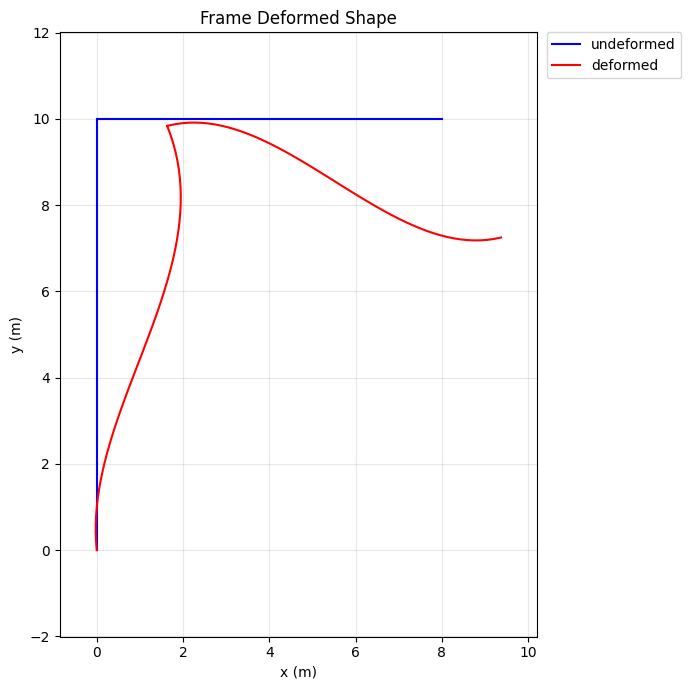

In [ ]:
# Question 1 plotting
plot_deformed_frame_2d(nodes, elements, u_global, scale=5.0)

### Comparison with hand calculation results

My computed results match my hand calculations. I checked this by comparing the fixed-end forces (FEFs), u_global, support reactions, and member end forces at each element end. The deformed shape also matched my hand sketch based on the signs and relative magnitudes of the displacement and rotation components.

## Response (Question 2)

ADD YOUR TEXT AND OUTPUT PLOTS AND TABLES HERE

In [ ]:
# Question 2

# -------------------------
# Problem data (hard-coded)
# -------------------------
E_GPa  = 200.0
A_mm2  = 4740.0
I_mm4  = 22.2e6
alpha = 12e-6

# Convert to kN/m^2, m^2, m^4
E_kNm2 = E_GPa * 1e6       # 1 GPa = 1e6 kN/m^2  -> 200 GPa = 200e6 kN/m^2
A_m2   = A_mm2 * 1e-6      # mm^2 -> m^2
I_m4   = I_mm4 * 1e-12     # mm^4 -> m^4

# Example element length (use your actual L for each member)
L1 = 10.0  # m
L2 = 8.0   # m
L = {
    1: L1,
    2: L2
}

nodes = {
    1: (0.0, 0.0),
    2: (0.0, 10.0),
    3: (8.0, 10.0),
}

elements = {
    1: (1, 2),
    2: (2, 3),
}

# ============================================================
# Member 1
# ============================================================
i=1
k1 = frame_k_local_2d(E_kNm2, A_m2, I_m4, L[i])

Qf1 = np.array([0., 120.0, 200., 0.0, 120., -200.], dtype=float)
Qf1_T = Qf_temp_local(E_kNm2, alpha, A_m2, I_m4, Tb=10.0, Tt=10.0, d=0.3)
Qf1 += Qf1_T

T1 = element_T_csL(nodes[elements[i][0]], nodes[elements[i][1]])

m1 = np.array([1, 2, 3, 4, 5, 6], dtype=int)  # 1-based DOF map

# ============================================================
# Member 2
# ============================================================
i=2
k2 = frame_k_local_2d(E_kNm2, A_m2, I_m4, L[i])

Qf2 = np.array([0., 37.5, 75., 0., 37.5, -75.], dtype=float)
Qf2_T = Qf_temp_local(E_kNm2, alpha, A_m2, I_m4, Tb=15.0, Tt=5.0, d=0.3)
Qf2 += Qf2_T

T2 = element_T_csL(nodes[elements[i][0]], nodes[elements[i][1]])

m2 = np.array([4, 5, 6, 7, 8, 9], dtype=int)  # 1-based DOF map

# -------------------------
# Initialize Global System
# -------------------------
k_list = [k1, k2]
T_list = [T1, T2]
Qf_list = [Qf1, Qf2]
map_list = [m1, m2]   # 1-based DOF maps

# Global system size (still using 1-based maps here)
ndof = int(np.max(np.concatenate(map_list)))

# Initialize Applied Load
F_global = np.zeros(ndof, dtype=float)

# Initialize Global Displacement
u_global = np.zeros(ndof, dtype=float)

# Restrained DOFs
dof_restrained_1based = np.array([1, 2, 3, 7, 8], dtype=int)

# Fictitious restrained DOFs
dof_fictitious_1based = np.array([], dtype=int)

# Combine and sort
dof_restrained_1based = np.sort(
    np.concatenate((dof_restrained_1based, dof_fictitious_1based))
)

# -------------------------
# Solve by DSM
# -------------------------
res = solve_partitioned_dsm(
    ndof=ndof,
    k_list=k_list,
    T_list=T_list,
    Qf_list=Qf_list,
    map_list=map_list,
    F_global=F_global,
    u_global=u_global,
    dof_restrained_1based=dof_restrained_1based,
)

u_global = res["u_global"]
f_global_complete = res["f_global_complete"]

# -------------------------
# Display DSM Results
# -------------------------
# Print the final global displacement vector and force vector.

print_dsm_results(
    u_global,
    f_global_complete,
    dof_restrained_1based,
    disp_in_mm=True
)

# -------------------------
# Display Element Results
# -------------------------
# Compute and print the element-level results for each member.

print_element(1, u_global, m1, T1, k1, Qf1, disp_in_mm=True, dec=1, rad_dec=6)
print_element(2, u_global, m2, T2, k2, Qf2, disp_in_mm=True, dec=1, rad_dec=6)

# -------------------------
# Print Support Reactions
# -------------------------
print(np.round(f_global_complete[dof_restrained_1based - 1], 3))

 DOF  Type Status  Disp (mm / rad)  Load (kN / kN·m)
   1   u_x  Fixed            0.000          -126.558
   2   u_y  Fixed            0.000            57.035
   3 theta  Fixed            0.000           221.860
   4   u_x   Free           -0.003             0.000
   5   u_y   Free            0.598             0.000
   6 theta   Free            0.025             0.000
   7   u_x  Fixed            0.000          -113.442
   8   u_y  Fixed            0.000            17.965
   9 theta   Free            0.022             0.000

E1
u [mm,rad]: [0.0, 0.0, 0.000000, -0.0, 0.6, 0.024618]
v [mm,rad]: [0.0, 0.0, 0.000000, 0.6, 0.0, 0.024618]
q [kN,kN·m]: [57.0, 126.6, 221.9, -57.0, 113.4, -156.3]

E2
u [mm,rad]: [-0.0, 0.6, 0.024618, 0.0, 0.0, 0.022162]
v [mm,rad]: [-0.0, 0.6, 0.024618, 0.0, 0.0, 0.022162]
q [kN,kN·m]: [113.4, 57.0, 156.3, -113.4, 18.0, -0.0]
[-126.558   57.035  221.86  -113.442   17.965]


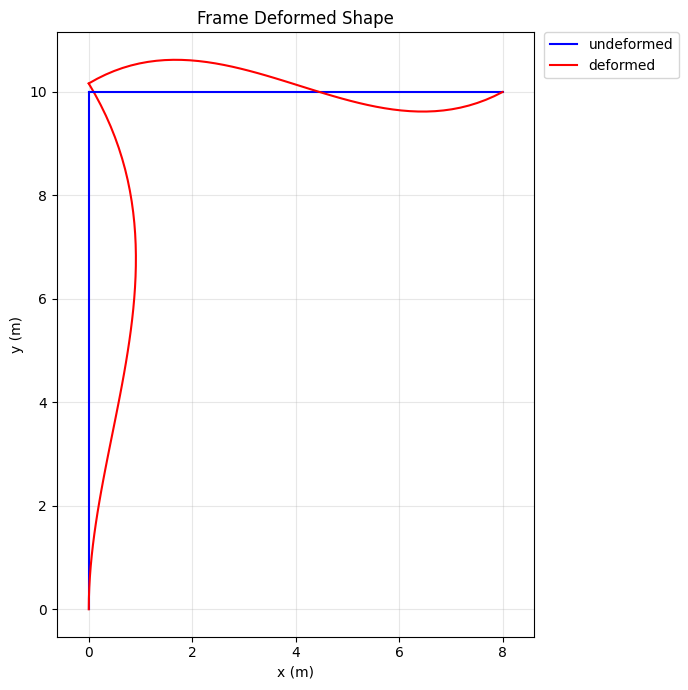

In [ ]:
# Question 2
plot_deformed_frame_2d(nodes, elements, u_global, scale=5.0)

### Comparison with hand calculation results

My computed results match my hand calculations. I checked this by comparing the fixed-end forces (FEFs), u_global, support reactions, and member end forces at each element end. The deformed shape also matched my hand sketch based on the signs and relative magnitudes of the displacement and rotation components.

## Response (Question 3)

ADD YOUR TEXT AND OUTPUT PLOTS AND TABLES HERE

In [ ]:
# Question 3

# -------------------------
# Problem data (hard-coded)
# -------------------------
E_GPa  = 200.0
A_mm2  = 4740.0
I_mm4  = 22.2e6

# Convert to kN/m^2, m^2, m^4
E_kNm2 = E_GPa * 1e6       # 1 GPa = 1e6 kN/m^2  -> 200 GPa = 200e6 kN/m^2
A_m2   = A_mm2 * 1e-6      # mm^2 -> m^2
I_m4   = I_mm4 * 1e-12     # mm^4 -> m^4

# Example element length (use your actual L for each member)
L1 = 10.0  # m
L2 = 8.0   # m
L = {
    1: L1,
    2: L2
}

nodes = {
    1: (0.0, 0.0),
    2: (0.0, 10.0),
    3: (8.0, 10.0),
}

elements = {
    1: (1, 2),
    2: (2, 3),
}

alpha = 12e-6

# ============================================================
# Member 1
# ============================================================
i=1
k1 = frame_k_local_2d(E_kNm2, A_m2, I_m4, L[i])

Qf1 = np.array([0., 120.0, 200., 0.0, 120., -200.], dtype=float)
Qf1_fab = Qf_fab_axial_local(E_kNm2, A_m2, L1, e_a=-0.003)
Qf1 += Qf1_fab

T1 = element_T_csL(nodes[elements[i][0]], nodes[elements[i][1]])

m1 = np.array([1, 2, 3, 4, 5, 6], dtype=int)  # 1-based DOF map

# ============================================================
# Member 2
# ============================================================
i=2
k2 = frame_k_local_2d(E_kNm2, A_m2, I_m4, L[i])

Qf2 = np.array([0., 37.5, 75., 0., 37.5, -75.], dtype=float)
Qf2_fab = Qf_fab_axial_local(E_kNm2, A_m2, L2, e_a=-0.003)
Qf2 += Qf2_fab

T2 = element_T_csL(nodes[elements[i][0]], nodes[elements[i][1]])

m2 = np.array([4, 5, 6, 7, 8, 9], dtype=int)  # 1-based DOF map

# -------------------------
# Initialize Global System
# -------------------------
k_list = [k1, k2]
T_list = [T1, T2]
Qf_list = [Qf1, Qf2]
map_list = [m1, m2]   # 1-based DOF maps

# Global system size (still using 1-based maps here)
ndof = int(np.max(np.concatenate(map_list)))

# Initialize Applied Load
F_global = np.zeros(ndof, dtype=float)

# Initialize Global Displacement
u_global = np.zeros(ndof, dtype=float)

# Restrained DOFs
dof_restrained_1based = np.array([1, 2, 3, 7, 8], dtype=int)

# Fictitious restrained DOFs
dof_fictitious_1based = np.array([], dtype=int)

# Combine and sort
dof_restrained_1based = np.sort(
    np.concatenate((dof_restrained_1based, dof_fictitious_1based))
)

# -------------------------
# Solve by DSM
# -------------------------
res = solve_partitioned_dsm(
    ndof=ndof,
    k_list=k_list,
    T_list=T_list,
    Qf_list=Qf_list,
    map_list=map_list,
    F_global=F_global,
    u_global=u_global,
    dof_restrained_1based=dof_restrained_1based,
)

u_global = res["u_global"]
f_global_complete = res["f_global_complete"]

# -------------------------
# Display DSM Results
# -------------------------
# Print the final global displacement vector and force vector.

print_dsm_results(
    u_global,
    f_global_complete,
    dof_restrained_1based,
    disp_in_mm=True
)

# -------------------------
# Display Element Results
# -------------------------
# Compute and print the element-level results for each member.

print_element(1, u_global, m1, T1, k1, Qf1, disp_in_mm=True, dec=1, rad_dec=6)
print_element(2, u_global, m2, T2, k2, Qf2, disp_in_mm=True, dec=1, rad_dec=6)

# -------------------------
# Print Support Reactions
# -------------------------
print(np.round(f_global_complete[dof_restrained_1based - 1], 3))

 DOF  Type Status  Disp (mm / rad)  Load (kN / kN·m)
   1   u_x  Fixed            0.000          -126.961
   2   u_y  Fixed            0.000            56.743
   3 theta  Fixed            0.000           223.555
   4   u_x   Free            3.954             0.000
   5   u_y   Free           -3.599             0.000
   6 theta   Free            0.025             0.000
   7   u_x  Fixed            0.000          -113.039
   8   u_y  Fixed            0.000            18.257
   9 theta   Free            0.022             0.000

E1
u [mm,rad]: [0.0, 0.0, 0.000000, 4.0, -3.6, 0.025340]
v [mm,rad]: [0.0, 0.0, 0.000000, -3.6, -4.0, 0.025340]
q [kN,kN·m]: [56.7, 127.0, 223.6, -56.7, 113.0, -153.9]

E2
u [mm,rad]: [4.0, -3.6, 0.025340, 0.0, 0.0, 0.021788]
v [mm,rad]: [4.0, -3.6, 0.025340, 0.0, 0.0, 0.021788]
q [kN,kN·m]: [113.0, 56.7, 153.9, -113.0, 18.3, 0.0]
[-126.961   56.743  223.555 -113.039   18.257]


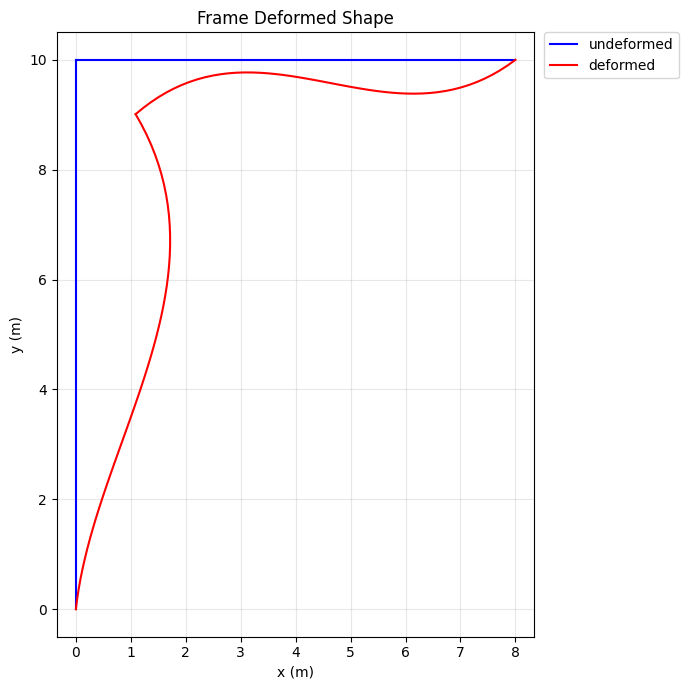

In [ ]:
# Question 3 plotting
plot_deformed_frame_2d(nodes, elements, u_global, scale=5.0)

### Comparison with hand calculation results

My computed results match my hand calculations. I checked this by comparing the fixed-end forces (FEFs), u_global, support reactions, and member end forces at each element end. The deformed shape also matched my hand sketch based on the signs and relative magnitudes of the displacement and rotation components.

---

## Reflection (Required)

In 3–6 sentences:

- What part felt easiest? Describe in speciics
- What part felt hardest? Describe in speciics
- One bug you encountered and how you fixed it.
- One thing you still don’t understand.
- If you used collaboration or AI tools, briefly describe how.


### YOUR RESPONSE HERE

Question 1 was the easiest because it only required assigning the prescribed values into u_global without creating any additional functions.
Creating the fixed-end force (FEF) functions for Questions 2 and 3 was not too difficult, but it required careful attention to the correct formulas and sign conventions.
I did not encounter any major bugs, and there were no remaining concepts that I felt I did not understand.
I mainly used AI for grammar checking and formatting.